In [2]:
## EXERCISE 1

In [3]:
# Packages
import pandas as pd
import numpy as np

# Visualisation packages
import matplotlib.pyplot as plt
from matplotlib import rc
import matplotlib.colors as mcolors
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio


In [4]:
phd_simp_df = pd.read_csv(
    "C:\\Users\\emmhu\\OneDrive\\Documents\\E-LEARNING\\DU DATA ANALYST\\5_Techniques de visualisation\\Données\\PhD_simp_latin1.csv",
    delimiter=","
)

phd_simp_df.head()


,Nom Prénom,Discipline,Année,Origine
0,Alice Johnson,Physique,1997,Asie
1,Frank Williams,SHS,2003,Asie
2,Ivy Miller,Physique,2010,Océanie
3,Jack Miller,SHS,1995,Océanie
4,Bob Rodriguez,SHS,2014,Océanie


In [5]:
print(phd_simp_df.shape)
print(phd_simp_df.info())
print(phd_simp_df.describe(include='all'))

(10000, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Nom Prénom  10000 non-null  object
 1   Discipline  10000 non-null  object
 2   Année       10000 non-null  int64 
 3   Origine     10000 non-null  object
dtypes: int64(1), object(3)
memory usage: 312.6+ KB
None
        Nom Prénom     Discipline         Année Origine
count        10000          10000  10000.000000   10000
unique         100              4           NaN       5
top     Ivy Miller  Mathématiques           NaN  Europe
freq           123           2570           NaN    2085
mean           NaN            NaN   2001.807400     NaN
std            NaN            NaN      9.650846     NaN
min            NaN            NaN   1985.000000     NaN
25%            NaN            NaN   1994.000000     NaN
50%            NaN            NaN   2002.000000     NaN
75%            NaN       

In [6]:
# We can observe this dataset is composed of 4 columns and 10000 rows. Only 'Année' column contains integer values, other columns contain string values

In [7]:
# Check for missing data
print(phd_simp_df.isna().sum())

Nom Prénom    0
Discipline    0
Année         0
Origine       0
dtype: int64


In [8]:
# Detecting non-standard entries in categorical data
print(phd_simp_df['Nom Prénom'].unique())

['Alice Johnson' 'Frank Williams' 'Ivy Miller' 'Jack Miller'
 'Bob Rodriguez' 'Hannah Miller' 'Frank Miller' 'Jack Martinez'
 'Hannah Martinez' 'Frank Garcia' 'David Smith' 'Grace Garcia'
 'David Rodriguez' 'Eve Davis' 'Jack Williams' 'Ivy Johnson' 'Alice Brown'
 'Frank Martinez' 'Alice Miller' 'Eve Williams' 'Charlie Miller'
 'Ivy Garcia' 'Charlie Jones' 'Hannah Williams' 'David Brown'
 'David Garcia' 'Frank Jones' 'Hannah Rodriguez' 'Hannah Davis'
 'Alice Garcia' 'Hannah Jones' 'Alice Smith' 'Grace Brown' 'Hannah Brown'
 'Charlie Brown' 'Eve Smith' 'Eve Rodriguez' 'Ivy Rodriguez' 'Alice Davis'
 'Charlie Garcia' 'Bob Jones' 'Grace Martinez' 'David Martinez'
 'Jack Garcia' 'Frank Davis' 'Hannah Smith' 'Frank Smith' 'Bob Smith'
 'Jack Smith' 'Eve Miller' 'David Jones' 'Ivy Jones' 'Ivy Williams'
 'Grace Davis' 'Ivy Brown' 'Hannah Johnson' 'Charlie Williams'
 'Eve Johnson' 'Jack Johnson' 'Alice Williams' 'Charlie Rodriguez'
 'Jack Rodriguez' 'Bob Brown' 'Grace Johnson' 'Alice Jones'
 'Cha

In [9]:
print(phd_simp_df['Discipline'].unique())

['Physique' 'SHS' 'Informatique' 'Mathématiques']


In [10]:
print(phd_simp_df['Année'].unique())

[1997 2003 2010 1995 2014 1992 2008 2011 2016 2009 1998 1996 1987 1991
 2017 2004 2006 2015 2007 1988 2013 1990 1985 1986 2000 2012 2018 1999
 1993 2005 2002 1994 2001 1989]


In [11]:
print(phd_simp_df['Origine'].unique())   

['Asie' 'Océanie' 'Afrique' 'Europe' 'Amérique']


In [12]:
# This dataset doesn't contain missing values. We haven't found irregular values neither.

In [13]:
# Step 1 - Aggregate the data : count the quantity of PhD thesis by dicipline from 1985 to 2018
pd.set_option('display.max_rows', 500)
discipline_count1= phd_simp_df.groupby('Année')['Discipline'].value_counts().reset_index(name= 'Count')
discipline_count1.head(10)

# I get results but in this case it is better to use .size(). Size() works directly on groupby() objects, allowing me to group by multiple 
# columns (Année and Discipline) and then count the occurrences of each combination. Value_counts() is for single Columns.

,Année,Discipline,Count
0,1985,Informatique,70
1,1985,SHS,61
2,1985,Physique,59
3,1985,Mathématiques,55
4,1986,Informatique,67
5,1986,Physique,67
6,1986,SHS,64
7,1986,Mathématiques,59
8,1987,Informatique,62
9,1987,Mathématiques,59


In [14]:
# Step 1 - Aggregate the data : count the quantity of PhD thesis by dicipline from 1985 to 2018
pd.set_option('display.max_rows', 500)
discipline_count2= phd_simp_df.groupby(['Année','Discipline']).size().reset_index(name= 'Count')
discipline_count2.head(10)

,Année,Discipline,Count
0,1985,Informatique,70
1,1985,Mathématiques,55
2,1985,Physique,59
3,1985,SHS,61
4,1986,Informatique,67
5,1986,Mathématiques,59
6,1986,Physique,67
7,1986,SHS,64
8,1987,Informatique,62
9,1987,Mathématiques,59


In [15]:
# WITH MATPLOTLIB

# Pivot the data
pivot_data = discipline_count2.pivot(index='Année', columns='Discipline', values='Count')
print(pivot_data.head(10))

# (optionnal) Handle missing values by filling them with 0 if it has not done before
# pivot_data = pivot_data.fillna(0)

Discipline  Informatique  Mathématiques  Physique  SHS
Année                                                 
1985                  70             55        59   61
1986                  67             59        67   64
1987                  62             59        55   56
1988                  84             83        79   89
1989                  76             77        68   72
1990                  70             62        53   71
1991                  68             70        68   86
1992                  65             85        55   85
1993                  63             77        57   69
1994                  82             70        64   92


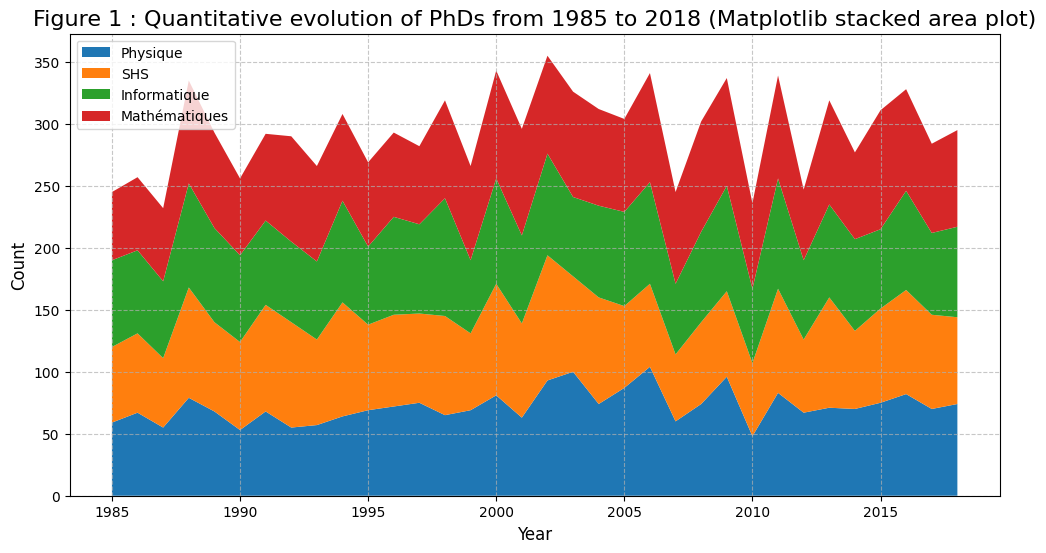

In [16]:
# Plot the stacked area chart with Matplotlib
plt.figure(figsize= (12,6))
plt.stackplot(pivot_data.index, # X-axis: Years
              pivot_data['Physique'], # y-values for Physique Discipline
              pivot_data['SHS'], # y-values for SHS Discipline
              pivot_data['Informatique'], # y-values for Informatique Discipline
              pivot_data['Mathématiques'], # y-values for Mathématiques Discipline
              labels= ['Physique', 'SHS', 'Informatique', 'Mathématiques'] # Proper labels
              )

# Customize the chart
plt.title('Figure 1 : Quantitative evolution of PhDs from 1985 to 2018 (Matplotlib stacked area plot)', fontsize= 16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.savefig('Figure1_Quantitative_evolution_of_phds_from_1985_to_2018_(Matplotlib_stacked_area_plot).png', dpi=300)
plt.show()

In [17]:
# WITH PLOTLY

#  Plot the stacked area chart with Plotly
fig = px.area(
    discipline_count2,
    x='Année',
    y='Count',
    color='Discipline',
    title='Figure 2 : Evolution of PhDs by discipline(Plotly stacked area plot)',
    color_discrete_sequence=px.colors.qualitative.Set2
)

plt.savefig('Figure2_quantitative_evolution_of_phds_from_1985_to_2018_(Plotly_stacked_area_plot).png', dpi=300)

# Show the plot
fig.show()


<Figure size 640x480 with 0 Axes>

In [18]:
# Create a stacked bar plot to show the quantitative evolution of PhDs from 1985 to 2018

# I am using the same dataset and I still need to pivot data in order to get data in a wide format (each column represents a separate category). 
# Consequently i can do the same operations until I need to plot the stacked bar

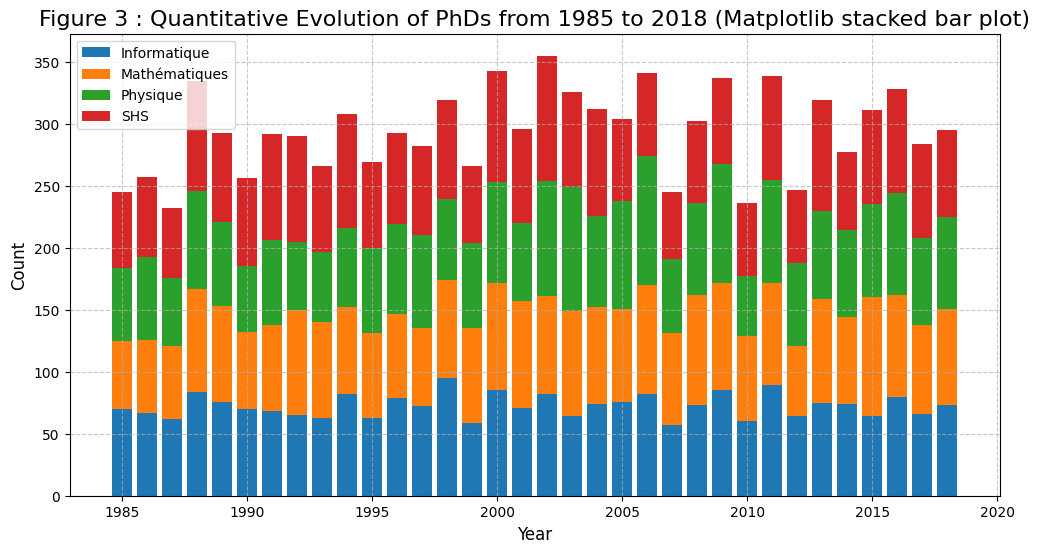

In [19]:
# WITH MATPLOTLIB

# Step 4 - Identifying parameters
y1= pivot_data['Informatique']
y2= pivot_data['Mathématiques']
y3= pivot_data['Physique']
y4= pivot_data['SHS']

# Plot the stacked bars
plt.figure(figsize= (12,6))
plt.bar(pivot_data.index, y1, label='Informatique')  # First category (no bottom needed)
plt.bar(pivot_data.index, y2, bottom=y1, label='Mathématiques')  # Stack on top of Informatique
plt.bar(pivot_data.index, y3, bottom=y1 + y2, label='Physique')  # Stack on top of Informatique + Mathématiques
plt.bar(pivot_data.index, y4, bottom=y1 + y2 + y3, label='SHS')  # Stack on top of all previous

# Customize the plot
plt.title('Figure 3 : Quantitative Evolution of PhDs from 1985 to 2018 (Matplotlib stacked bar plot)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

plt.savefig('Figure3_quantitative_evolution_of_phds_from_1985_to_2018_(Matplotlib_stacked_bar_plot).png', dpi=300)
plt.show()

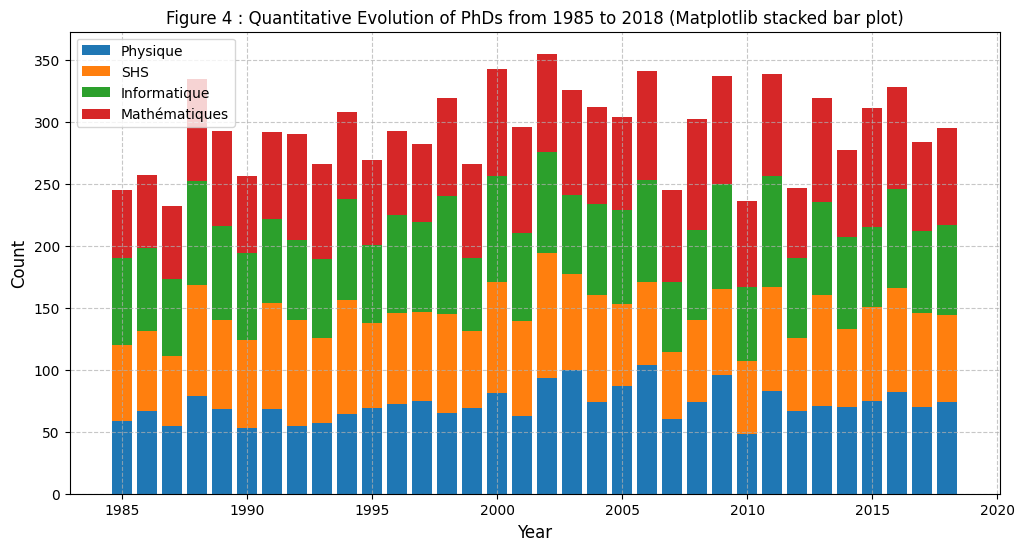

In [20]:
# OR

# Plot the stacked bars
plt.figure(figsize=(12,6))
bottom = 0 # Initialize stacking


# Iterate over each discipline dynamically
for discipline in ['Physique', 'SHS', 'Informatique', 'Mathématiques']:
    plt.bar(
        pivot_data.index,  # X-axis: Use the index (years)
        pivot_data[discipline],  # Y-axis: Data for the current discipline
        bottom=bottom,  # Stack on top of the previous discipline
        label=discipline  # Add the discipline name for the legend
    )
    # Update the bottom to include the current discipline
    bottom += pivot_data[discipline]
    
# Customize the plot
plt.title('Figure 4 : Quantitative Evolution of PhDs from 1985 to 2018 (Matplotlib stacked bar plot)')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

plt.savefig('Figure4_quantitative_evolution_of_phds_from_1985_to_2018_(Matplotlib_stacked_bar_plot).png', dpi=300)
plt.show()

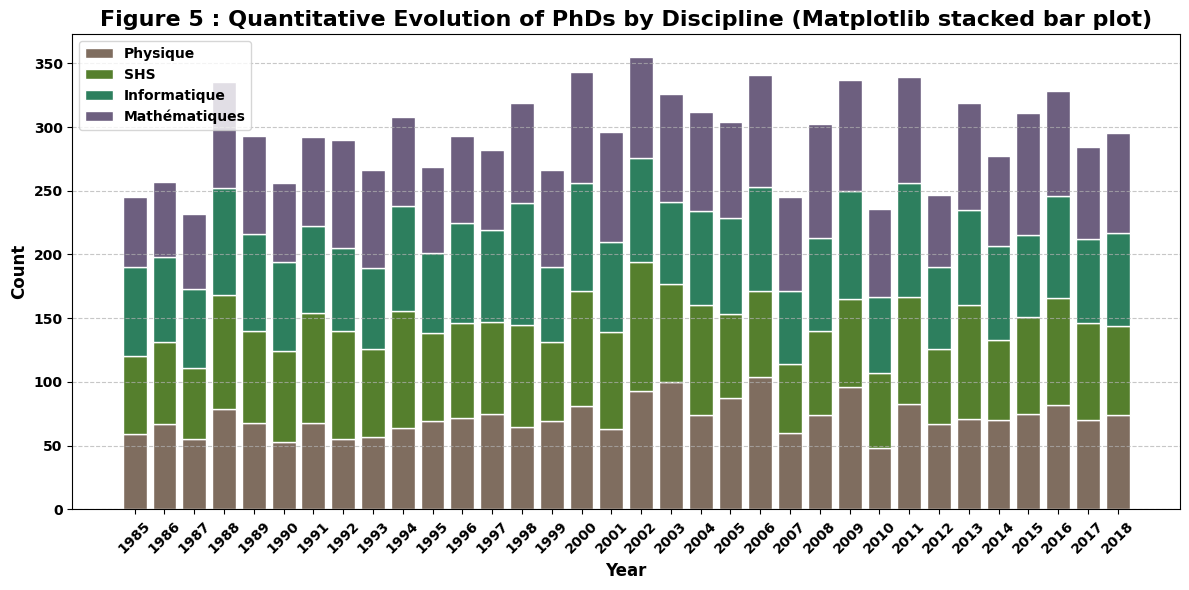

In [21]:
# OR

# Plot the stacked bars (as in https://python-graph-gallery.com/12-stacked-barplot-with-matplotlib/)

# Ensure y-axis font is bold
rc('font', weight='bold')

# Values of each group (Extract data from pivot_data)
bars1 = pivot_data['Physique']
bars2 = pivot_data['SHS']
bars3 = pivot_data['Informatique']
bars4 = pivot_data['Mathématiques']

# Compute cumulative heights for stacking
bars_12 = np.add(bars1, bars2).tolist()  # Physique + SHS
bars_123 = np.add(bars_12, bars3).tolist()  # Physique + SHS + Informatique

# The positions of the bars on the x-axis
r = np.arange(len(pivot_data.index))  # Dynamically set positions based on number of years

# Names of groups (Years) and bar width
names = pivot_data.index.tolist()  # Use the years (Année) from pivot_data
barWidth = 0.8  # Adjust bar width for better visualization

# Plot the bars
plt.figure(figsize=(12, 6))

# Create bars for each discipline
plt.bar(r, bars1, color='#7f6d5f', edgecolor='white', width=barWidth, label='Physique')
plt.bar(r, bars2, bottom=bars1, color='#557f2d', edgecolor='white', width=barWidth, label='SHS')
plt.bar(r, bars3, bottom=bars_12, color='#2d7f5e', edgecolor='white', width=barWidth, label='Informatique')
plt.bar(r, bars4, bottom=bars_123, color='#6d5f7f', edgecolor='white', width=barWidth, label='Mathématiques')

# Customize x-axis
plt.xticks(r, names, fontweight='bold', rotation=45)  # Rotate labels for better readability
plt.xlabel("Year", fontsize=12, fontweight='bold')
plt.ylabel("Count", fontsize=12, fontweight='bold')

# Add a title and legend
plt.title('Figure 5 : Quantitative Evolution of PhDs by Discipline (Matplotlib stacked bar plot)', fontsize=16, fontweight='bold')
plt.legend(loc='upper left')  # Add a legend
plt.grid(axis='y', linestyle='--', alpha=0.7)  # Add gridlines for clarity

# Show the plot

plt.savefig('Figure5_quantitative_evolution_of_phds_from_1985_to_2018_(Matplotlib_stacked_bar_plot).png', dpi=300)
plt.tight_layout()  # Ensure the layout fits well
plt.show()

In [22]:
# WITH PLOTLY

# Create the figure
fig = go.Figure()

# Loop through each discipline and add a bar trace
for discipline in pivot_data.columns:
    fig.add_trace(
        go.Bar(
            x=pivot_data.index,
            y=pivot_data[discipline],
            name=discipline
        )
    )

# Customize the layout
fig.update_layout(
    title='Figure 6 : Quantitative evolution of PhDs from 1985 to 2018(Plotly stacked bar plot)',
    xaxis_title='Year',
    yaxis_title='Number of PhDs',
    barmode='stack',
    template='plotly_white'
)

plt.savefig('Figure6_quantitative_evolution_of_phds_from_1985_to_2018_(Plotly_stacked_bar_plot).png', dpi=300)

# Show the plot
fig.show()

<Figure size 640x480 with 0 Axes>

In [23]:
# Create a stacked bar plot
fig = px.bar(
    discipline_count2,
    x='Année',
    y='Count',
    color='Discipline',
    title='Figure 7 : Quantitative evolution of PhDs from 1985 to 2018 (plotly stacked bar plot)',
    labels={'Année': 'Year', 'Count': 'Number of PhDs'},
    color_discrete_sequence=px.colors.qualitative.Set2
)

plt.savefig('Figure7_quantitative_evolution_of_phds_from_1985_to_2018_(Plotly_stacked_bar_plot).png', dpi=300)

# Show the plot
fig.show()



<Figure size 640x480 with 0 Axes>

In [24]:
## EXERCISE 2

In [25]:
phd_simp_df.head()

,Nom Prénom,Discipline,Année,Origine
0,Alice Johnson,Physique,1997,Asie
1,Frank Williams,SHS,2003,Asie
2,Ivy Miller,Physique,2010,Océanie
3,Jack Miller,SHS,1995,Océanie
4,Bob Rodriguez,SHS,2014,Océanie


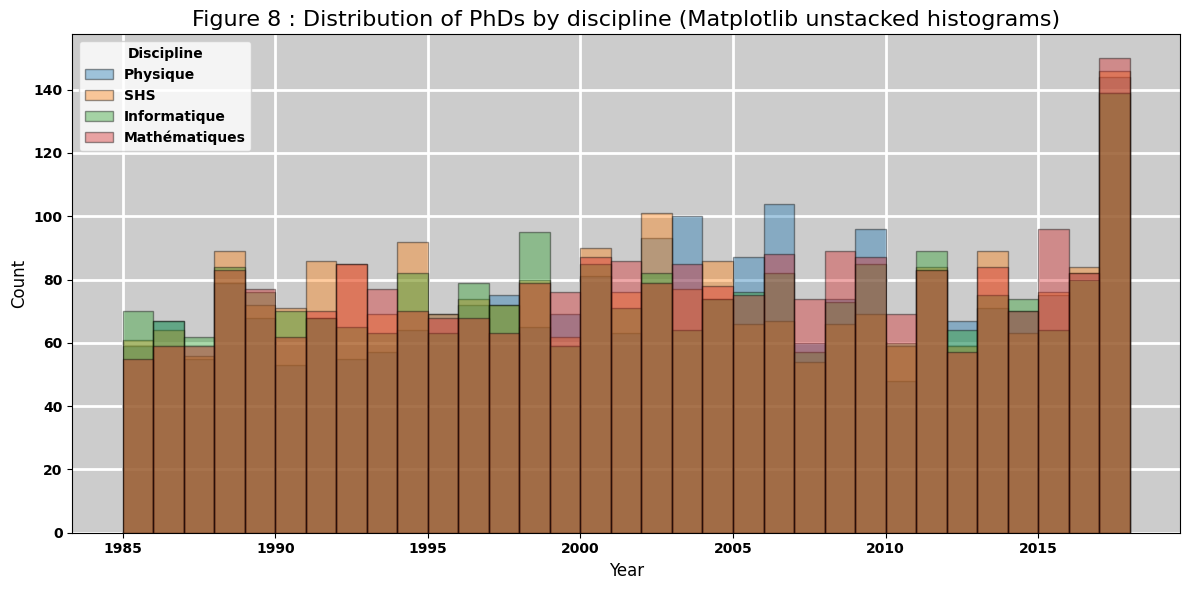

In [26]:
# WITH MATPLOTLIB

# List of disciplines
disciplines = phd_simp_df['Discipline'].unique()

# Define custom colors
color = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Matplotlib default palette


# Create the plot with matplotlib
plt.figure(figsize=(12, 6))

for discipline in disciplines:
    # Filter data for the current discipline
    years = phd_simp_df[phd_simp_df['Discipline'] == discipline]['Année']
    plt.hist(years, bins=range(1985, 2019), alpha=0.4, label=discipline,edgecolor='black', zorder=3)  # alpha for transparency

# Add labels, title, and legend
plt.xlabel('Year', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Figure 8 : Distribution of PhDs by discipline (Matplotlib unstacked histograms)', fontsize=16)
plt.legend(title='Discipline', fontsize=10)


plt.savefig('Figure8_distribution_of_phds_by_discipline_(Matplotlib_unstacked_histograms).png', dpi=300)

# Show the plot
plt.grid(True, color='w', linestyle='-', linewidth=2, zorder=0)
plt.gca().patch.set_facecolor('0.8')
plt.tight_layout()
plt.show()

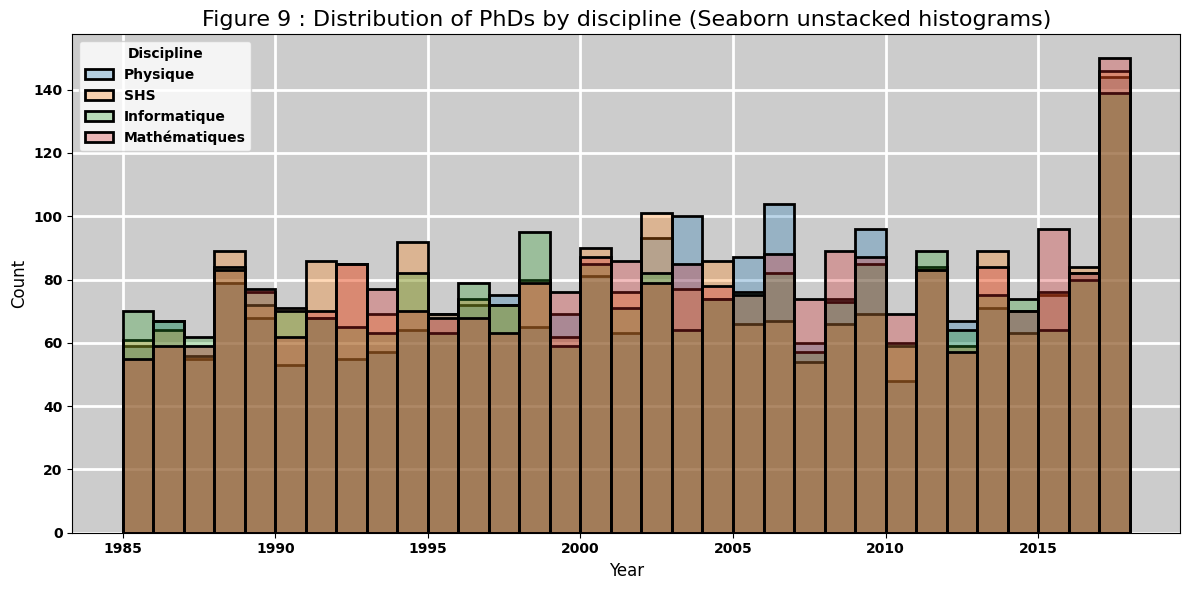

In [27]:
# Create the plot with seaborn
plt.figure(figsize=(12, 6))

# Plot histograms for each discipline with transparency
for discipline in disciplines:
    sns.histplot(phd_simp_df[phd_simp_df['Discipline'] == discipline], x='Année', bins=range(1985, 2019), 
                 kde=False, alpha=0.3, label=discipline, zorder=3, edgecolor='black',linewidth=2)

# Add labels, title, and legend
plt.xlabel('Year', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Figure 9 : Distribution of PhDs by discipline (Seaborn unstacked histograms)', fontsize=16)
plt.legend(title='Discipline', fontsize=10)
plt.grid()


plt.savefig('Figure9_distribution_of_phds_by_discipline_(Seaborn_unstacked_histograms).png', dpi=300)

# Show the plot
plt.grid(True, color='w', linestyle='-', linewidth=2, zorder=0)
plt.gca().patch.set_facecolor('0.8')
plt.tight_layout()
plt.show()

In [28]:
# Displaying all variables on the same  histogram graph, it becomes gradually difficult to read information. Using Alpha helps. 
# Additionnally, we can observe set up colors change because of overlapping. Choosing histograms for this question, as on the figure n°1, wasn't a good idea. 
# Consequently, we looked for a better alternative, to display all discipline slightly shifting the position of each discipline's bars along 
# the x-axis so that they no longer overlap. We used offset.

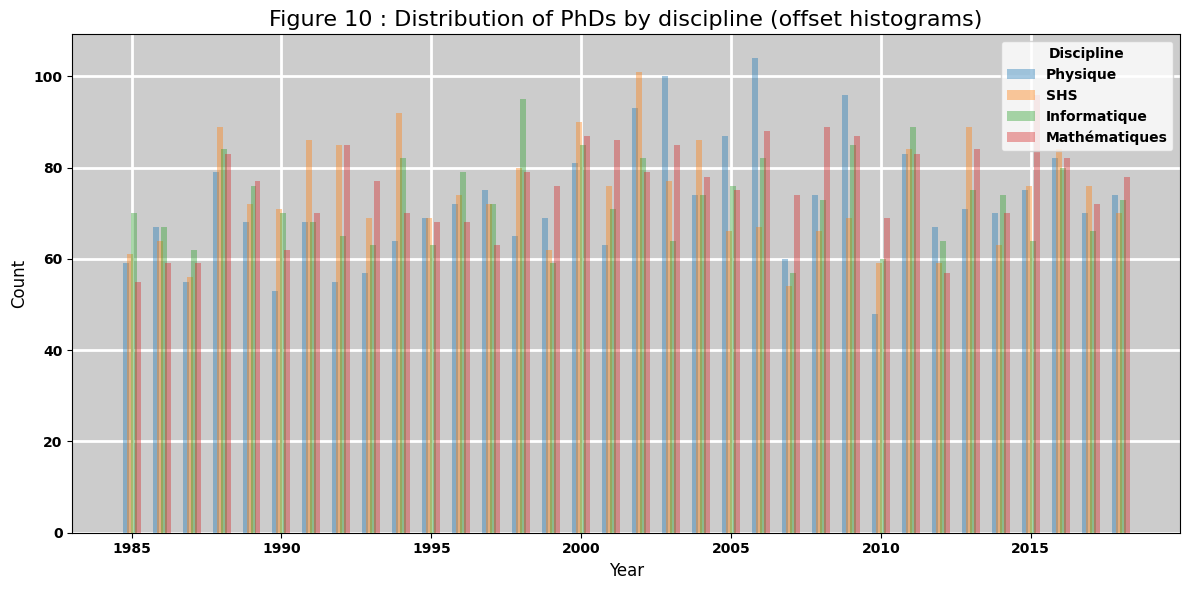

In [29]:
# List of disciplines
disciplines = phd_simp_df['Discipline'].unique()

# Define bar width and offsets
bar_width = 0.2  # Width of each bar
x = np.arange(1985, 2020)  # Define bins (years)
offsets = np.linspace(-bar_width, bar_width, len(disciplines))  # Evenly space offsets

# Create the plot
plt.figure(figsize=(12, 6))

for discipline, offset in zip(disciplines, offsets):
    # Filter data for the current discipline
    years = phd_simp_df[phd_simp_df['Discipline'] == discipline]['Année']
    counts, bins = np.histogram(years, bins=x)
    plt.bar(bins[:-1] + offset, counts, width=bar_width, label=discipline, alpha=0.4, zorder=3)

# Add labels, title, and legend
plt.xlabel('Year', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.title('Figure 10 : Distribution of PhDs by discipline (offset histograms)', fontsize=16)
plt.legend(title='Discipline', fontsize=10)

plt.savefig('Figure10_distribution_of_phds_by_discipline_(offset_histograms).png', dpi=300)

# Show the plot
plt.tight_layout()
plt.grid(True, color='w', linestyle='-', linewidth=2, zorder=0)
plt.gca().patch.set_facecolor('0.8')
plt.show()

In [30]:
# 1. Calculate total counts per discipline
total_counts = phd_simp_df['Discipline'].value_counts()

# 2. Calculate percentage contribution
percentages = total_counts / total_counts.sum() * 100

# 3. Summarize counts by year and discipline
melted_yearly_counts = phd_simp_df.groupby(['Année', 'Discipline']).size().unstack(fill_value=0)

# 4. Combine into a summary DataFrame
summary_df = pd.DataFrame({
    'Total Count': total_counts,
    'Percentage (%)': percentages
}).reset_index()

summary_df.rename(columns={'index': 'Discipline'}, inplace=True)

# Display the summary DataFrame
print("Overall Summary:")
print(summary_df)

# Display the yearly breakdown
print("\nYearly Breakdown:")
print(melted_yearly_counts)

Overall Summary:
      Discipline  Total Count  Percentage (%)
0  Mathématiques         2570           25.70
1            SHS         2514           25.14
2   Informatique         2469           24.69
3       Physique         2447           24.47

Yearly Breakdown:
Discipline  Informatique  Mathématiques  Physique  SHS
Année                                                 
1985                  70             55        59   61
1986                  67             59        67   64
1987                  62             59        55   56
1988                  84             83        79   89
1989                  76             77        68   72
1990                  70             62        53   71
1991                  68             70        68   86
1992                  65             85        55   85
1993                  63             77        57   69
1994                  82             70        64   92
1995                  63             68        69   69
1996               

In [31]:
## EXERCICE 3

In [32]:
# 1. Dans l’exercice 3, nous repartons sur des graphes non transparents, mais avec toujours une grille. Nous allons jouer sur la distance 
# entre l’axe et les labels correspondants. Dans la figure ci-dessous, nous illustrons comment pour l’axe des X, nous pouvons éloigner 
# les labels de l’axe (flèches rouges). Trouvez sur Internet la méthode pour le faire, et produisez un graphe avec les labels de l’axe
# X clairement décollés de l’axe

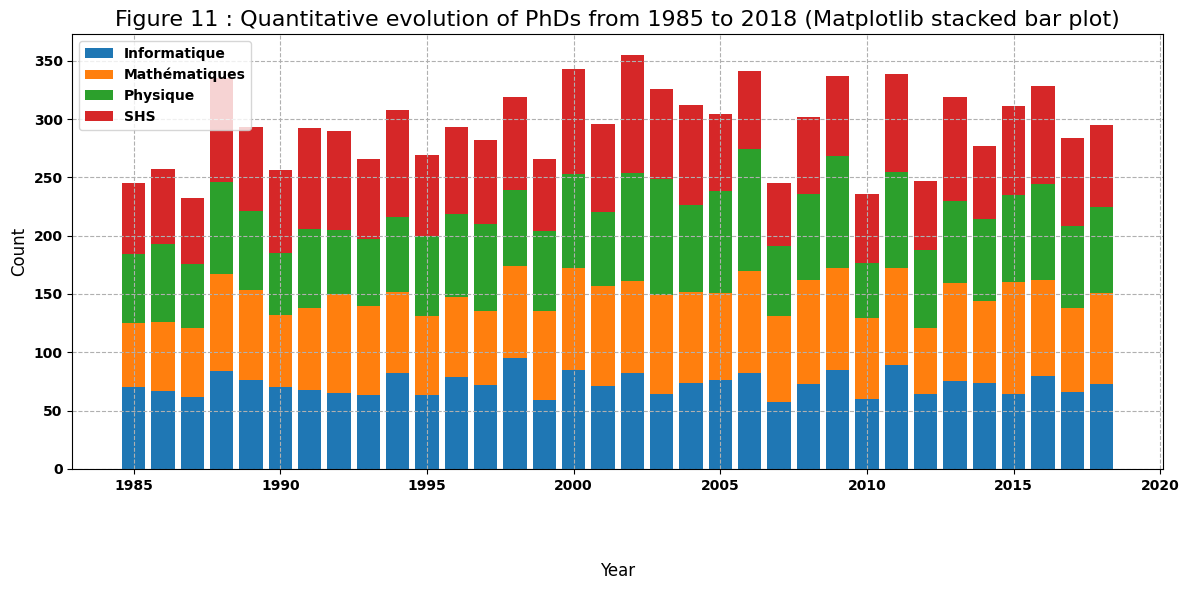

In [33]:
# Plot the stacked bars
plt.figure(figsize= (12,6))
plt.bar(pivot_data.index, y1, label='Informatique')  # First category (no bottom needed)
plt.bar(pivot_data.index, y2, bottom=y1, label='Mathématiques')  # Stack on top of Informatique
plt.bar(pivot_data.index, y3, bottom=y1 + y2, label='Physique')  # Stack on top of Informatique + Mathématiques
plt.bar(pivot_data.index, y4, bottom=y1 + y2 + y3, label='SHS')  # Stack on top of all previous

# Step 6 - Customize the plot
plt.title('Figure 11 : Quantitative evolution of PhDs from 1985 to 2018 (Matplotlib stacked bar plot)', fontsize=16)
plt.xlabel('Year', fontsize=12, labelpad= 50) # Raise the distance between x label and the graph
plt.ylabel('Count', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--')

plt.savefig('Figure11_quantitative_evolution_of_phds_from_1985_to_2018_(Matplotlib_stacked_bar_plot).png', dpi=300)

#Display the plot
plt.tight_layout()

In [34]:
# To move the 'Year' label far from X-axis I used labelpad when setting up the X label. To avoid the label being possibly cropped 
# I add bbox_inches='tight' when saving the plot.

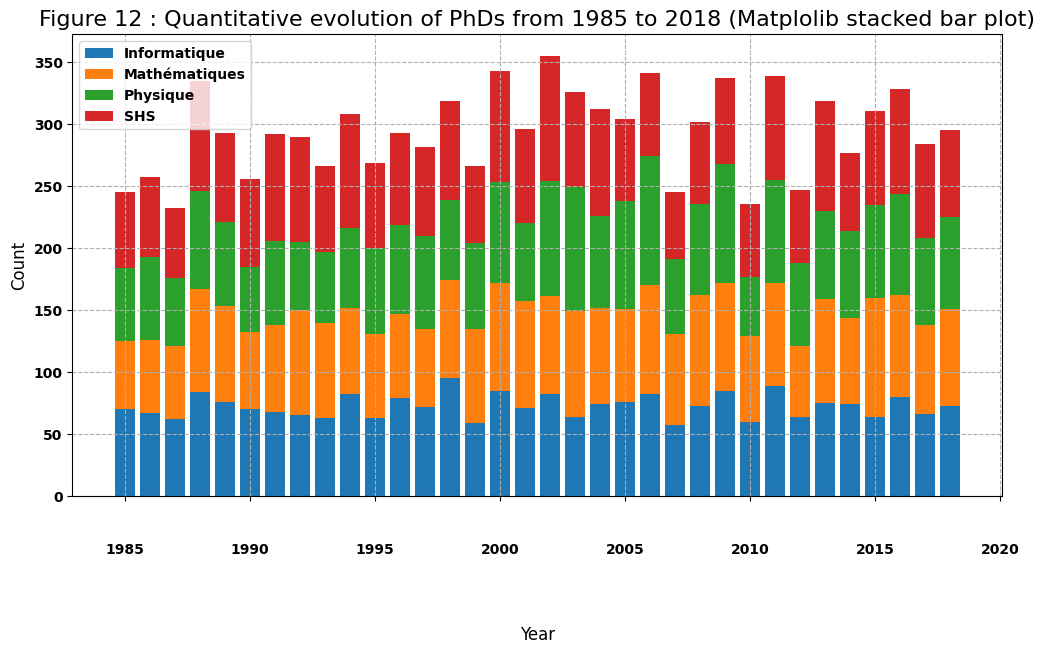

In [35]:
# Plot the stacked bars
plt.figure(figsize= (12,6))
plt.bar(pivot_data.index, y1, label='Informatique')  # First category (no bottom needed)
plt.bar(pivot_data.index, y2, bottom=y1, label='Mathématiques')  # Stack on top of Informatique
plt.bar(pivot_data.index, y3, bottom=y1 + y2, label='Physique')  # Stack on top of Informatique + Mathématiques
plt.bar(pivot_data.index, y4, bottom=y1 + y2 + y3, label='SHS')  # Stack on top of all previous

# Customize the plot
plt.gca().tick_params(axis='x', pad=30) # Move ticks away from X-axis
plt.title('Figure 12 : Quantitative evolution of PhDs from 1985 to 2018 (Matplolib stacked bar plot)', fontsize=16)
plt.xlabel('Year', fontsize=12, labelpad= 50) # Raise the distance between x-label and the graph
plt.ylabel('Count', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--')


plt.savefig('Figure12_quantitative_evolution_of_phds_from_1985_to_2018_(Matplotlib_stacked_bar_plot).png', dpi=300)

# Display the plot
plt.show()


In [36]:
# To move years itselves down, I add plt.gca().tick_params(axis='x', pad=30) when setting up labels, title and legend

In [37]:
# 2. Dans un second temps, produisez un graphique où ces labels sont légèrement inclinés de 45°. Ci-dessous, nous avons choisi un angle de 90°, 
# conservez quant à vous l’angle de 45°. Mot-clé : tilt

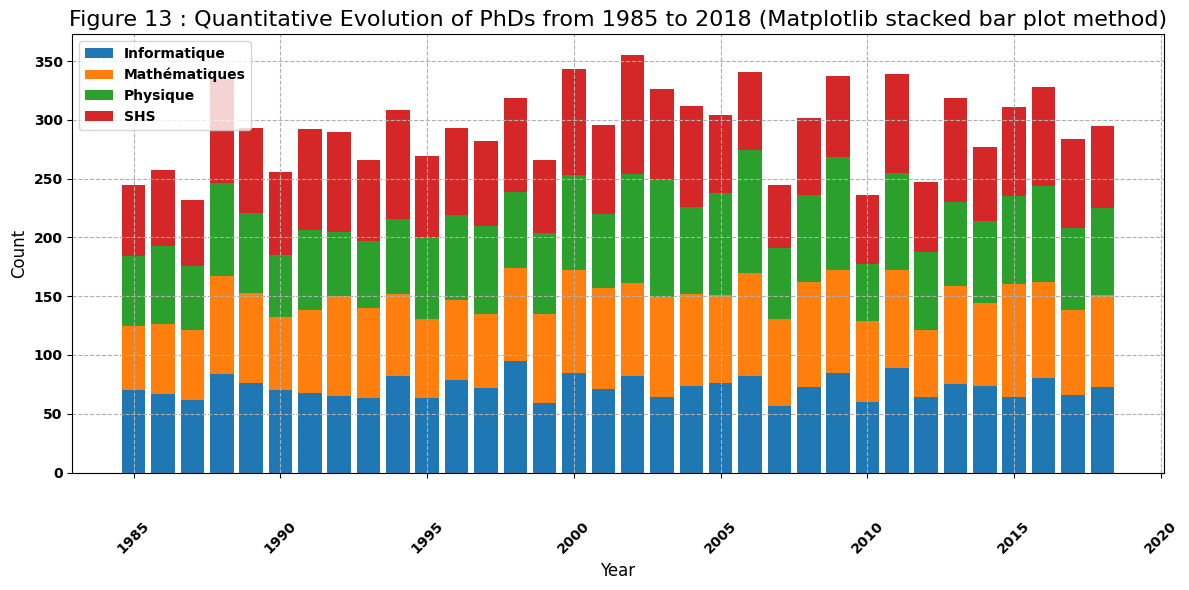

In [38]:
# Plot the stacked bars
plt.figure(figsize= (12,6))
plt.bar(pivot_data.index, y1, label='Informatique')  # First category (no bottom needed)
plt.bar(pivot_data.index, y2, bottom=y1, label='Mathématiques')  # Stack on top of Informatique
plt.bar(pivot_data.index, y3, bottom=y1 + y2, label='Physique')  # Stack on top of Informatique + Mathématiques
plt.bar(pivot_data.index, y4, bottom=y1 + y2 + y3, label='SHS')  # Stack on top of all previous

# Customize the plot
plt.gca().tick_params(axis='x', pad=30, rotation= 45) # Tilts the x-axis labels to 45°
plt.title('Figure 13 : Quantitative Evolution of PhDs from 1985 to 2018 (Matplotlib stacked bar plot method)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--')

plt.savefig('Figure13_quantitative_evolution_of_phds_from_1985_to_2018_(Matplotlib_stacked_bar_plot).png', dpi=300)

# Display the plot
plt.tight_layout()

In [39]:
# "tilt" typically refers to the rotation or inclination of the tick labels relative to the axis. This is often used to make tick labels more 
# readable when there are many labels or when they are long, such as dates or descriptive text.

#For instance:

    # 0°: Labels are horizontal.
    # 45°: Labels are diagonally tilted.
    # 90°: Labels are vertical.

In [40]:
## EXERCISE 4

In [41]:
# 1. Dans l’exercice 4, nous vous demandons de reproduire le même graphique, mais en changeant la police pour utiliser du Times New Roman ou du Garamond.
# Mot-clé pour R : extrafonts. Produisez ensuite différents graphiques pour montrer que vous êtes capables de jouer sur la taille de la police pour 
# les labels des axes et pour le titre. 

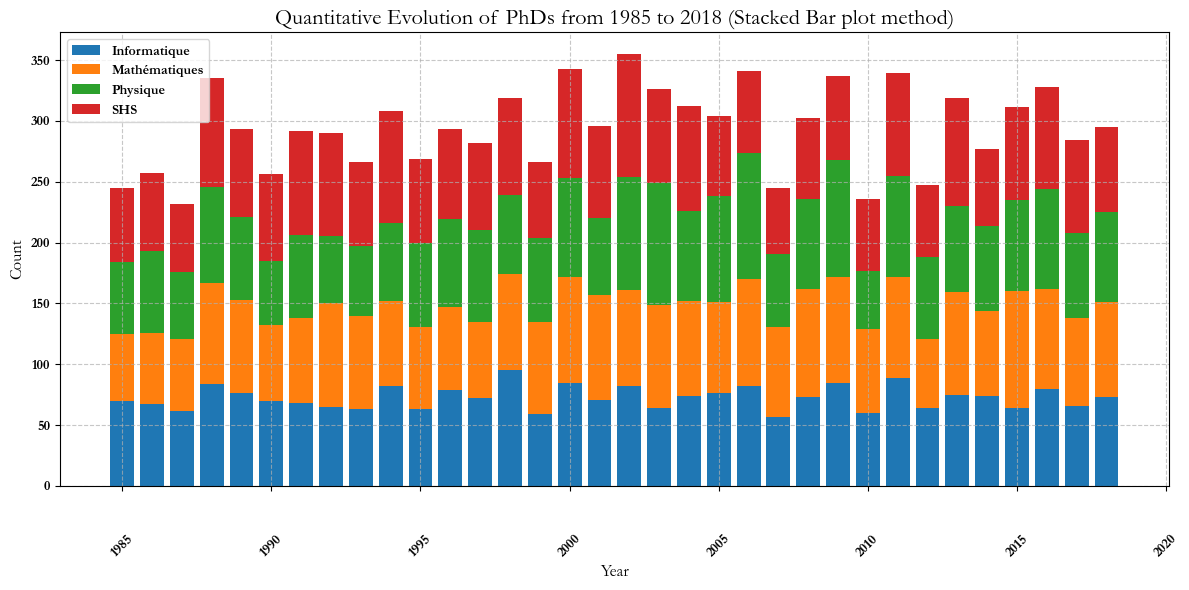

In [42]:
# Set global font to Times New Roman or Garamond
plt.rc('font', family='Garamond')


# Plot the stacked bars
plt.figure(figsize= (12,6))
plt.bar(pivot_data.index, y1, label='Informatique')  # First category (no bottom needed)
plt.bar(pivot_data.index, y2, bottom=y1, label='Mathématiques')  # Stack on top of Informatique
plt.bar(pivot_data.index, y3, bottom=y1 + y2, label='Physique')  # Stack on top of Informatique + Mathématiques
plt.bar(pivot_data.index, y4, bottom=y1 + y2 + y3, label='SHS')  # Stack on top of all previous

# Customize the plot
plt.gca().tick_params(axis='x', pad=30, rotation= 45) # Tilts the x-axis labels to 45°
plt.title('Quantitative Evolution of PhDs from 1985 to 2018 (Stacked Bar plot method)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

In [43]:
import matplotlib.font_manager

# Display the list of available font styles
print([f.name for f in matplotlib.font_manager.fontManager.ttflist])

['STIXGeneral', 'DejaVu Sans Mono', 'STIXSizeOneSym', 'STIXSizeThreeSym', 'DejaVu Sans Mono', 'STIXSizeTwoSym', 'DejaVu Serif', 'DejaVu Serif', 'cmmi10', 'DejaVu Sans Mono', 'STIXGeneral', 'STIXSizeFourSym', 'cmtt10', 'STIXSizeTwoSym', 'DejaVu Sans', 'STIXNonUnicode', 'STIXGeneral', 'STIXSizeFiveSym', 'DejaVu Sans', 'STIXNonUnicode', 'STIXNonUnicode', 'DejaVu Sans Mono', 'STIXGeneral', 'STIXSizeOneSym', 'cmsy10', 'cmss10', 'DejaVu Serif', 'DejaVu Serif', 'STIXSizeThreeSym', 'STIXSizeFourSym', 'cmr10', 'DejaVu Sans Display', 'STIXNonUnicode', 'cmb10', 'DejaVu Sans', 'DejaVu Sans', 'cmex10', 'DejaVu Serif Display', 'Trebuchet MS', 'Castellar', 'Bookman Old Style', 'Rockwell Extra Bold', 'Consolas', 'Ebrima', 'Georgia', 'Font Awesome 5 Free Solid', 'Palatino Linotype', 'Book Antiqua', 'Georgia', 'Corbel', 'Segoe MDL2 Assets', 'Corbel', 'Microsoft PhagsPa', 'Malgun Gothic', 'Consolas', 'Yu Gothic', 'Haettenschweiler', 'Leelawadee UI', 'Constantia', 'Lucida Console', 'Courier New', 'Bernard

In [44]:
# Package to correct ticks labels if when changing font size and font style Matplotlib automatically formatted them with a decimal point
from matplotlib.ticker import FormatStrFormatter
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import FuncFormatter

<Figure size 1200x600 with 0 Axes>

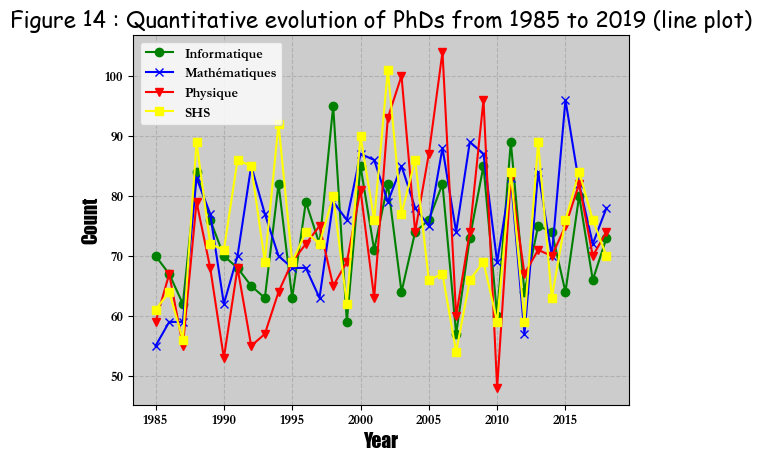

In [58]:
# Set global font size
plt.rc('font', size=10)  # Default font size for all elements
plt.rc('axes', titlesize=16)  # Font size for axis titles
plt.rc('axes', labelsize=14)  # Font size for axis labels
plt.rc('xtick', labelsize=10)  # Font size for x-axis ticks
plt.rc('ytick', labelsize=10)  # Font size for y-axis ticks
plt.rc('legend', fontsize=10)  # Font size for the legend

#plot a multiple line graph

plt.figure(figsize=(12,6))

fig, ax= plt.subplots()

ax.plot(pivot_data.index, pivot_data['Informatique'], color= 'Green', label='Informatique', marker= 'o')
ax.plot(pivot_data.index, pivot_data['Mathématiques'], color= 'Blue', label='Mathématiques', marker= 'x')
ax.plot(pivot_data.index, pivot_data['Physique'], color= 'Red', label='Physique', marker= 'v')
ax.plot(pivot_data.index, pivot_data['SHS'], color= 'Yellow', label='SHS', marker= 's')

# Customize plot
plt.title('Figure 14 : Quantitative evolution of PhDs from 1985 to 2019 (line plot)', fontname= 'Comic Sans MS')
plt.xlabel('Year', fontname= 'Impact')
plt.ylabel('Count',fontname= 'Impact')
plt.legend()
plt.grid(linestyle='--')
plt.gca().patch.set_facecolor('0.8')

plt.savefig('Figure14_quantitative_evolution_of_phds_from_1985_to_2018 (line_plot).png', dpi=300, bbox_inches='tight')


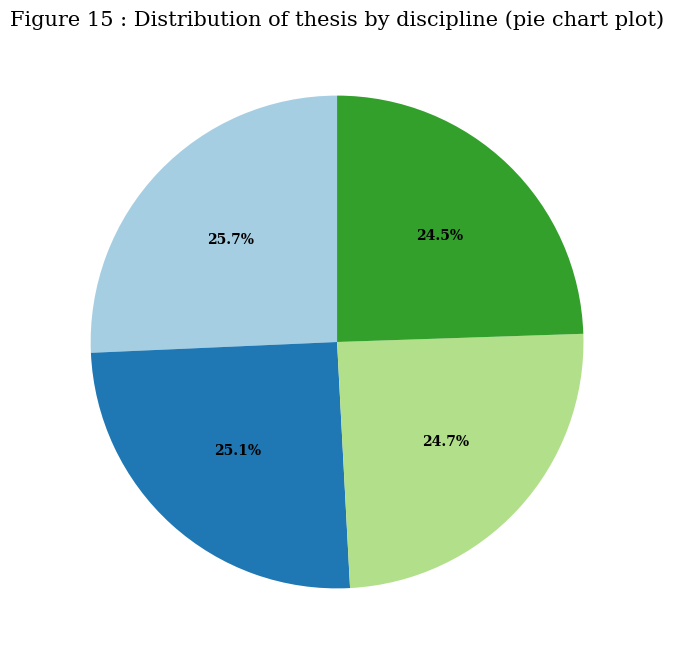

In [46]:
# Filtering for specific disciplines
selected_disciplines = ['Informatique', 'Mathématiques', 'Physique', 'SHS']
discipline_counts = phd_simp_df[phd_simp_df['Discipline'].isin(selected_disciplines)]['Discipline'].value_counts()

# Plotting the pie chart
plt.figure(figsize=(8, 8))
plt.pie(
    discipline_counts,
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Paired.colors,
    textprops={'fontsize': 10, 'fontname': 'DejaVu Serif'}
)

# Adding a title
plt.title('Figure 15 : Distribution of thesis by discipline (pie chart plot)', fontsize= 15, fontname='DejaVu Serif')

# Add a legend

plt.savefig('Figure15_distribution_of_thesis_by_discipline_(pie_chart_plot).png', dpi=300)

# Display the plot
plt.show()

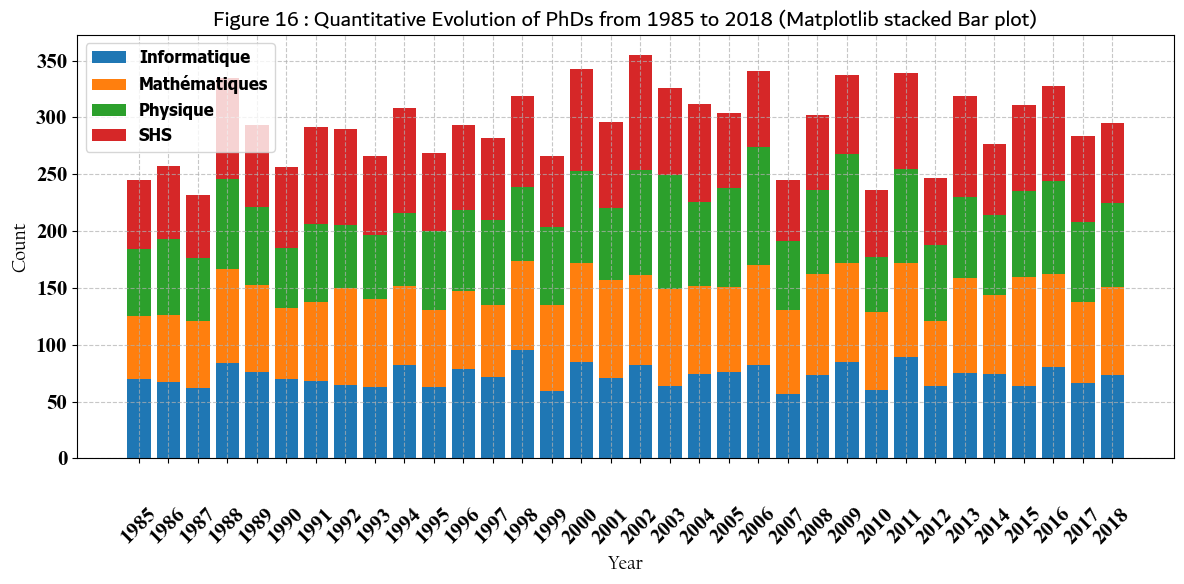

In [47]:
# Set global font size
plt.rc('font', size=12)  # Default font size for all elements
plt.rc('axes', titlesize=16)  # Font size for axis titles
plt.rc('axes', labelsize=14)  # Font size for axis labels
plt.rc('xtick', labelsize=10)  # Font size for x-axis ticks
plt.rc('ytick', labelsize=10)  # Font size for y-axis ticks
plt.rc('legend', fontsize=12)  # Font size for the legend

# Plot the stacked bars
plt.figure(figsize=(12, 6))
plt.bar(pivot_data.index, y1, label='Informatique')  # First category (no bottom needed)
plt.bar(pivot_data.index, y2, bottom=y1, label='Mathématiques')  # Stack on top of Informatique
plt.bar(pivot_data.index, y3, bottom=y1 + y2, label='Physique')  # Stack on top of Informatique + Mathématiques
plt.bar(pivot_data.index, y4, bottom=y1 + y2 + y3, label='SHS')  # Stack on top of all previous

# Customize the x-axis ticks to show integers only
plt.gca().tick_params(axis='x', pad=30, rotation=45)  # Tilts the x-axis labels to 45°
plt.gca().set_xticks(pivot_data.index)  # Ensure tick positions are correct
plt.gca().set_xticklabels([int(year) for year in pivot_data.index], fontsize=15, fontname="Times New Roman")

# Customize the y-axis ticks to show integers only
plt.gca().set_yticks(range(0, int(max(y1 + y2 + y3 + y4)) + 1, 50))  # Adjust range and step size
plt.gca().set_yticklabels([int(tick) for tick in plt.gca().get_yticks()], fontsize=15, fontname="Times New Roman")

# Customize the plot
plt.title('Figure 16 : Quantitative Evolution of PhDs from 1985 to 2018 (Matplotlib stacked Bar plot)', fontname="Dubai")
plt.xlabel('Year', fontname="Californian FB")
plt.ylabel('Count', fontname="Californian FB")
plt.legend(loc='upper left', prop={'family': 'Tahoma'})
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig('Figure16_quantitative_evolution_of_phds_from_1985_to_2018_(Matplotlib_stacked_bar_plot).png', dpi=300)

# Display the plot
plt.show()

In [48]:
# 2. Produisez un second graphique sur lequel vous jouez sur la taille des marges, pour ”écraser” un peu 
# le graphique vers le centre, comme dans la figure ci-dessous

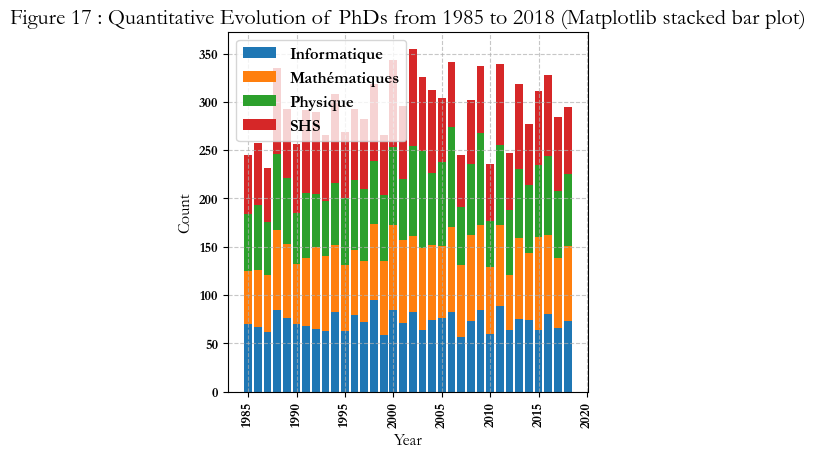

In [49]:
# Plot the stacked bars
plt.figure(figsize= (12,6))
plt.bar(pivot_data.index, y1, label='Informatique')  # First category (no bottom needed)
plt.bar(pivot_data.index, y2, bottom=y1, label='Mathématiques')  # Stack on top of Informatique
plt.bar(pivot_data.index, y3, bottom=y1 + y2, label='Physique')  # Stack on top of Informatique + Mathématiques
plt.bar(pivot_data.index, y4, bottom=y1 + y2 + y3, label='SHS')  # Stack on top of all previous

# Adjust margins
plt.gcf().subplots_adjust(left= 0.1, right= 0.4, top= 0.8, bottom= 0.2)

# Customize the plot
plt.gca().tick_params(axis='x', rotation= 90) # Tilts the x-axis labels to 90°
plt.title('Figure 17 : Quantitative Evolution of PhDs from 1985 to 2018 (Matplotlib stacked bar plot)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)


plt.savefig('Figure17_quantitative_evolution_of_phds_from_1985_to_2018_(Matplotlib_stacked_bar_plot).png', dpi=300)

# Display the plot
plt.show()

In [50]:
## EXERCISE 5

In [51]:
# Dans l’exercice 5, nous vous demandons de produire un graphe où vous changez l’échelle des Y par une échelle logarithmique. Cela ne présente que peu d’intérêt,
# c’est simplement pour être certain que vous êtes capable de le faire

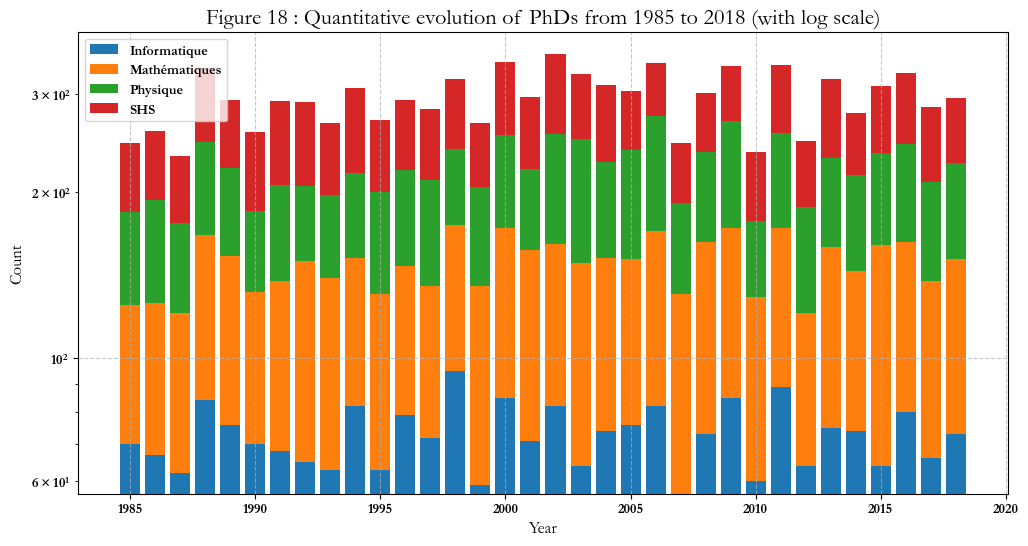

In [60]:
# Plot the stacked bars
plt.figure(figsize= (12,6))
plt.bar(pivot_data.index, y1, label='Informatique')  # First category (no bottom needed)
plt.bar(pivot_data.index, y2, bottom=y1, label='Mathématiques')  # Stack on top of Informatique
plt.bar(pivot_data.index, y3, bottom=y1 + y2, label='Physique')  # Stack on top of Informatique + Mathématiques
plt.bar(pivot_data.index, y4, bottom=y1 + y2 + y3, label='SHS')  # Stack on top of all previous

# Apply a  logarithmic scale on Y axis
plt.yscale('log')

# Customize the plot
plt.title('Figure 18 : Quantitative evolution of PhDs from 1985 to 2018 (with log scale)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

plt.savefig('Figure18_quantitative_evolution_of_phds_from_1985_to_2018_(with_log_scale).png', dpi=300)

# Display the plot
plt.show()

In [53]:
# A logarithmic scale is a type of scale used in graphs where each step on the scale represents a multiplicative change rather 
# than an additive change. In simpler terms, the values increase exponentially instead of linearly.

# A logarithmic scale is useful when working with data that spans a wide range of values. For instance, it could be population growth,
# earthquake magnitudes, financial data (revenues, stock prices), scientific data (sound intensity, pH levels, etc.).
# Instead of plotting values like 1, 2, 3, 4, a logarithmic scale plots values like 1, 10, 100, 1000, making it easier to see trends 
# in data with large variations.

In [54]:
## EXERCISE 6

In [55]:
# Dans l’exercice 6, nous vous demandons de jouer sur la position de la légende (reprenant les différentes disciplines). 
# Produisez des graphiques avec deux positions différentes de la légende

In [1]:
#plot a multiple line graph

plt.figure(figsize=(12,6))

fig, ax= plt.subplots()

ax.plot(pivot_data.index, pivot_data['Informatique'], color= 'Green', label='Informatique', marker= 'o')
ax.plot(pivot_data.index, pivot_data['Mathématiques'], color= 'Blue', label='Mathématiques', marker= 'x')
ax.plot(pivot_data.index, pivot_data['Physique'], color= 'Red', label='Physique', marker= 'v')
ax.plot(pivot_data.index, pivot_data['SHS'], color= 'Yellow', label='SHS', marker= 's')

# Customize plot
plt.title('Quantitative evolution of PhDs from 1985 to 2019')
plt.xlabel('Year', fontname= 'Impact')
plt.ylabel('Count',fontname= 'Impact')
plt.legend(loc= 'lower left', fontsize= 10)
plt.grid(linestyle='--')
plt.gca().patch.set_facecolor('0.8')


#plot a multiple line graph

plt.figure(figsize=(12,6))

fig, ax= plt.subplots()

ax.plot(pivot_data.index, pivot_data['Informatique'], color= 'Green', label='Informatique', marker= 'o')
ax.plot(pivot_data.index, pivot_data['Mathématiques'], color= 'Blue', label='Mathématiques', marker= 'x')
ax.plot(pivot_data.index, pivot_data['Physique'], color= 'Red', label='Physique', marker= 'v')
ax.plot(pivot_data.index, pivot_data['SHS'], color= 'Yellow', label='SHS', marker= 's')

# Customize plot
plt.title('Quantitative evolution of PhDs from 1985 to 2019', fontname= 'Comic Sans MS')
plt.xlabel('Year', fontname= 'Impact')
plt.ylabel('Count',fontname= 'Impact')
plt.legend(loc= 'upper left', fontsize= 10)
plt.grid(linestyle='--')
plt.gca().patch.set_facecolor('0.8')


NameError: name 'plt' is not defined

In [188]:
## EXERCISE 7

In [189]:
# Dans l’exercice 7, changez la palette de couleur utilisée pour représenter les différentes disciplines.

In [190]:
# Existing colors
print(mcolors.TABLEAU_COLORS) # Most used colors
print(mcolors.XKCD_COLORS) # full list of 949 colors available in the Matplotlib package

{'tab:blue': '#1f77b4', 'tab:orange': '#ff7f0e', 'tab:green': '#2ca02c', 'tab:red': '#d62728', 'tab:purple': '#9467bd', 'tab:brown': '#8c564b', 'tab:pink': '#e377c2', 'tab:gray': '#7f7f7f', 'tab:olive': '#bcbd22', 'tab:cyan': '#17becf'}
{'xkcd:cloudy blue': '#acc2d9', 'xkcd:dark pastel green': '#56ae57', 'xkcd:dust': '#b2996e', 'xkcd:electric lime': '#a8ff04', 'xkcd:fresh green': '#69d84f', 'xkcd:light eggplant': '#894585', 'xkcd:nasty green': '#70b23f', 'xkcd:really light blue': '#d4ffff', 'xkcd:tea': '#65ab7c', 'xkcd:warm purple': '#952e8f', 'xkcd:yellowish tan': '#fcfc81', 'xkcd:cement': '#a5a391', 'xkcd:dark grass green': '#388004', 'xkcd:dusty teal': '#4c9085', 'xkcd:grey teal': '#5e9b8a', 'xkcd:macaroni and cheese': '#efb435', 'xkcd:pinkish tan': '#d99b82', 'xkcd:spruce': '#0a5f38', 'xkcd:strong blue': '#0c06f7', 'xkcd:toxic green': '#61de2a', 'xkcd:windows blue': '#3778bf', 'xkcd:blue blue': '#2242c7', 'xkcd:blue with a hint of purple': '#533cc6', 'xkcd:booger': '#9bb53c', 'xkcd

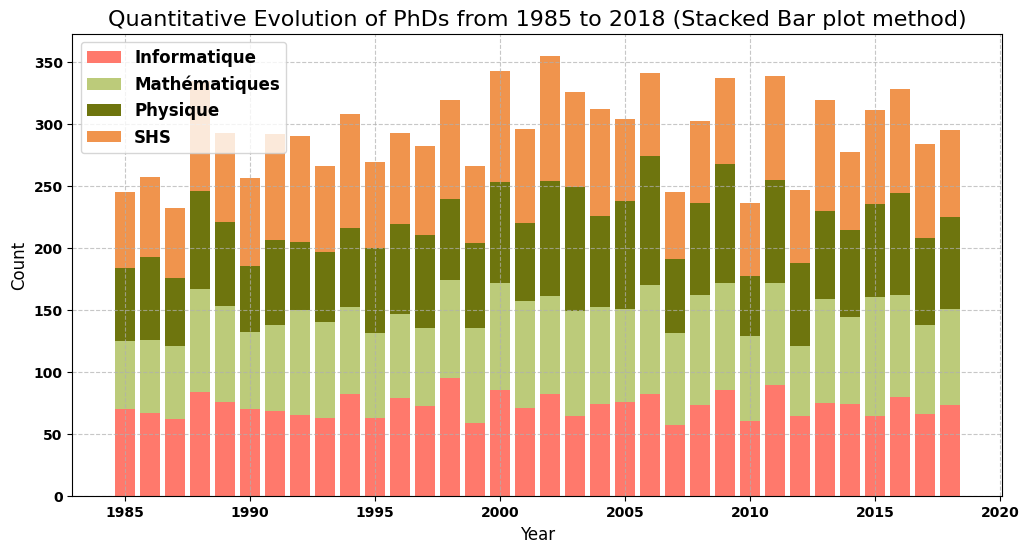

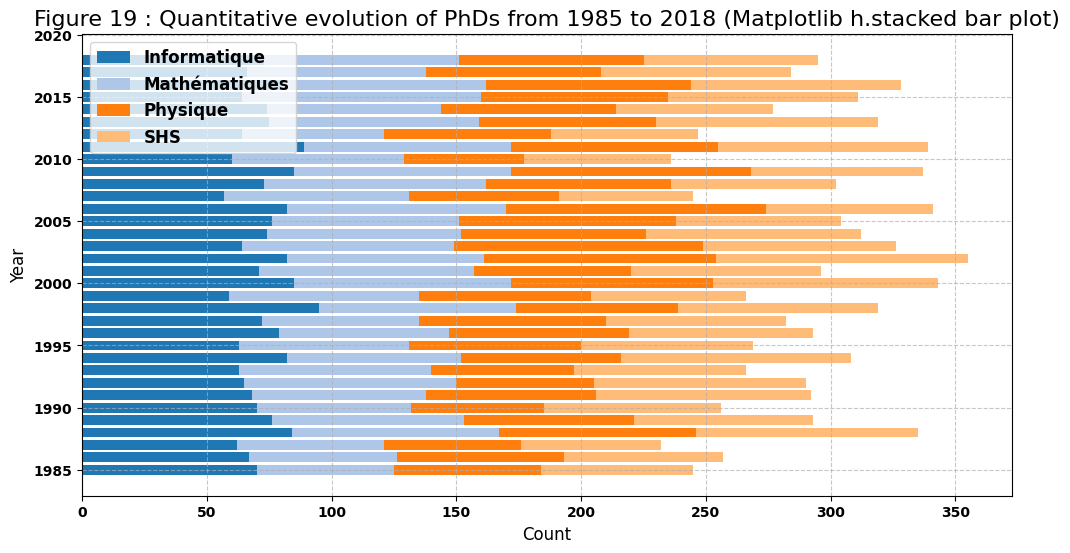

In [51]:
#Setting color palette
color_sets = ['#ff796c','#bccb7a','#6e750e', '#f0944d']

# Plot
plt.figure(figsize= (12,6))
plt.bar(pivot_data.index, y1, label='Informatique', color=color_sets[0])
plt.bar(pivot_data.index, y2, bottom=y1, label='Mathématiques', color=color_sets[1]) 
plt.bar(pivot_data.index, y3, bottom=y1 + y2, label='Physique', color=color_sets[2])  
plt.bar(pivot_data.index, y4, bottom=y1 + y2 + y3, label='SHS', color=color_sets[3]) 

# Customize the plot
plt.title('Quantitative Evolution of PhDs from 1985 to 2018 (Stacked Bar plot method)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# OR

# Generate a dynamic color palette
num_sections = 4  # Adjust this to match the number of bar sections
color_sets = sns.color_palette('tab20', num_sections)

# Plot
plt.figure(figsize= (12,6))
plt.barh(pivot_data.index, y1, label='Informatique', color=color_sets[0])
plt.barh(pivot_data.index, y2, left=y1, label='Mathématiques', color=color_sets[1]) 
plt.barh(pivot_data.index, y3, left=y1 + y2, label='Physique', color=color_sets[2])  
plt.barh(pivot_data.index, y4, left=y1 + y2 + y3, label='SHS', color=color_sets[3]) 

# Customize the plot
plt.title('Figure 19 : Quantitative evolution of PhDs from 1985 to 2018 (Matplotlib h.stacked bar plot)', fontsize=16)
plt.xlabel('Count', fontsize=12)
plt.ylabel('Year', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)

plt.savefig('Figure19_quantitative_evolution_of_phds_from_1985_to_2018_(Matplotlib_h.stacked_bar_plot).png', dpi=300)

# Display the plot
plt.show()




In [192]:
## EXERCISE 8

In [193]:
# Dans l’exercice 8, changez l’ordre (de bas en haut) dans lequel apparaissent les disciplines. Par exemple, si la biologie est en bas, 
# touchant l’axe des X, elle doit apparaître en haut.

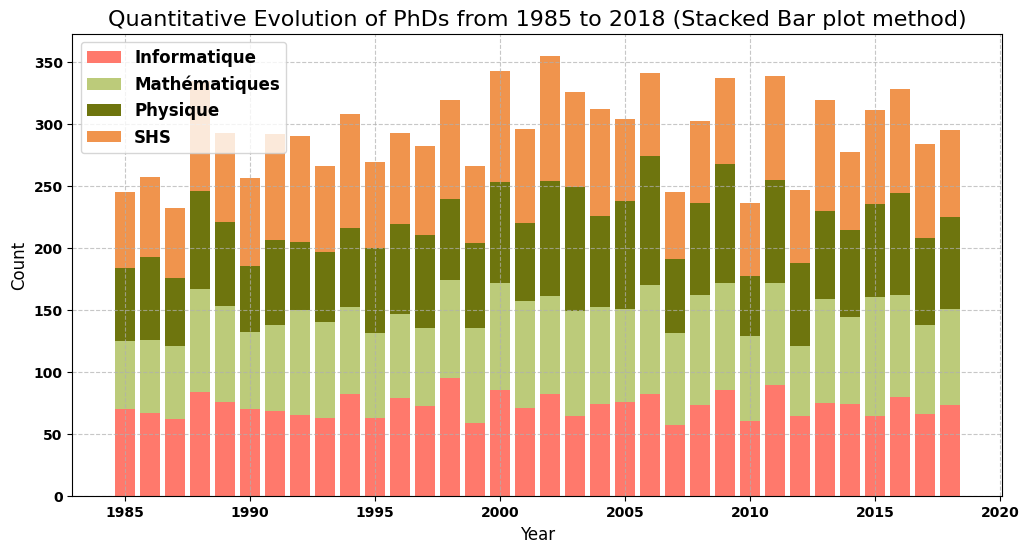

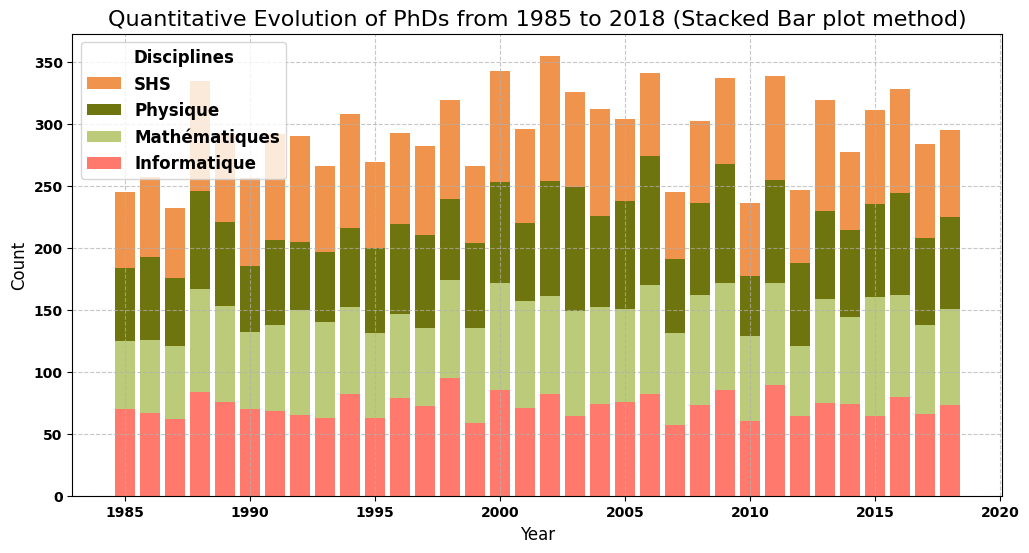

In [52]:
#Setting color palette
color_sets = ['#ff796c','#bccb7a','#6e750e', '#f0944d']

# Plot
plt.figure(figsize= (12,6))
plt.bar(pivot_data.index, y1, label='Informatique', color=color_sets[0])
plt.bar(pivot_data.index, y2, bottom=y1, label='Mathématiques', color=color_sets[1]) 
plt.bar(pivot_data.index, y3, bottom=y1 + y2, label='Physique', color=color_sets[2])  
plt.bar(pivot_data.index, y4, bottom=y1 + y2 + y3, label='SHS', color=color_sets[3]) 

# Customize the plot
plt.title('Quantitative Evolution of PhDs from 1985 to 2018 (Stacked Bar plot method)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


#Setting color palette
color_sets = ['#ff796c','#bccb7a','#6e750e', '#f0944d']

# Plot
plt.figure(figsize= (12,6))
plt.bar(pivot_data.index, y1, label='Informatique', color=color_sets[0])
plt.bar(pivot_data.index, y2, bottom=y1, label='Mathématiques', color=color_sets[1]) 
plt.bar(pivot_data.index, y3, bottom=y1 + y2, label='Physique', color=color_sets[2])  
plt.bar(pivot_data.index, y4, bottom=y1 + y2 + y3, label='SHS', color=color_sets[3]) 

# Customize the plot
plt.title('Quantitative Evolution of PhDs from 1985 to 2018 (Stacked Bar plot method)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Count', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.7)

# Reordering the labels 
handles, labels = plt.gca().get_legend_handles_labels() 
  
# Specify the custom order for the legend
custom_order = [3, 2, 1, 0]  # Move 'SHS' to the top

# Apply the reordered legend
plt.legend([handles[i] for i in custom_order], [labels[i] for i in custom_order], title="Disciplines")


plt.show()

In [195]:
## EXERCISE 9

In [196]:
# Dans cet exercice, nous vous laissons toute latitude pour choisir ce que vous souhaitez représenter à partir du jeu de données sur les thèses. Nous vous
# donnons une seule contrainte : incorporez comme dans la figure ci-dessous un ”slider” (barre horizontale sur laquelle vous pouvez faire varier le temps, 
# entre autres). Vous devrez utiliser plotly, que ce soit sur R ou sur Python. Il n’y a pas obligation à produire un bubble plot, qui ne sert ici que 
# d’illustration pour le slider. Vous devrez ensuite produire un second graphique, mais utilisant cette fois un ”selector”. 

# Vous réaliserez des exports au format html des widgets produits, que vous soumettrez ensuite en addition du rapport et du notebook Jupyter

In [53]:
print(phd_simp_df)

            Nom Prénom     Discipline  Année  Origine
0        Alice Johnson       Physique   1997     Asie
1       Frank Williams            SHS   2003     Asie
2           Ivy Miller       Physique   2010  Océanie
3          Jack Miller            SHS   1995  Océanie
4        Bob Rodriguez            SHS   2014  Océanie
...                ...            ...    ...      ...
9995   Charlie Johnson  Mathématiques   1996     Asie
9996      David Garcia       Physique   2018  Océanie
9997      Hannah Smith       Physique   2004     Asie
9998  Charlie Martinez            SHS   2018   Europe
9999     Charlie Jones  Mathématiques   1987   Europe

[10000 rows x 4 columns]


In [54]:
# Aggregate the data : count the quantity of PhD thesis by dicipline from 1985 to 2018
pd.set_option('display.max_rows', 500)
discipline_count2= phd_simp_df.groupby(['Année','Discipline']).size().reset_index(name= 'Count')
discipline_count2.head(10)

,Année,Discipline,Count
0,1985,Informatique,70
1,1985,Mathématiques,55
2,1985,Physique,59
3,1985,SHS,61
4,1986,Informatique,67
5,1986,Mathématiques,59
6,1986,Physique,67
7,1986,SHS,64
8,1987,Informatique,62
9,1987,Mathématiques,59


In [55]:
# Create the figure
fig = go.Figure()

# Create the bar plot with a slider
fig = px.bar(discipline_count2, 
             x='Discipline', 
             y='Count', color='Discipline', 
             animation_frame='Année', 
             title='Figure 20 : Quantitative Evolution of PhDs from 1985 to 2019 (Plotly slider plot)',
             labels={'Année': 'Year', 'Count': 'Number of PhDs'},
             color_discrete_sequence=px.colors.qualitative.Set2
)

# Customize layout
fig.update_layout(
    xaxis_title='Discipline',
    yaxis_title='Number of PhDs',
    template='plotly_white',
    showlegend=False
)

# Save the Plotly widget as a standalone HTML file
html_content = fig.to_html(full_html=False)

# Write only the slider widget to an HTML file
with open("slider_interactive_widget.html", "w") as file:
    file.write(html_content)

plt.savefig('Figure20_quantitative_evolution_of_phds_from_1985_to_2018_(Plotly_slider_plot).png', dpi=300)

# Show the plot
fig.show()


<Figure size 640x480 with 0 Axes>

In [56]:
# Export the full interactive Plotly widget as an HTML file
fig.write_html("full_slider_plot_interactive_widget.html")

In [57]:
# Aggregate the data : count the quantity of PhD thesis by dicipline from 1985 to 2018
discipline_count2= phd_simp_df.groupby(['Année','Discipline']).size().reset_index(name= 'Count')
discipline_count2.head(10)


# Define a professional color palette
colors = {
    'Informatique': '#1f77b4',  # Blue
    'Mathématiques': '#ff7f0e',  # Orange
    'Physique': '#2ca02c',  # Green
    'SHS': '#d62728'  # Red
}

# Create the figure
fig = go.Figure()

# Loop through each discipline to add a line trace
for discipline in discipline_count2['Discipline'].unique():
    discipline_df = discipline_count2[discipline_count2['Discipline'] == discipline]
    
    # Add a line trace for each discipline
    fig.add_trace(go.Scatter(
        x=discipline_df['Année'],
        y=discipline_df['Count'],
        mode='lines',
        name=discipline,
        line=dict(color=colors[discipline], width=3),
    ))

# Create dropdown buttons for each discipline
dropdown_buttons = [
    {'label': 'All', 'method': 'update', 'args': [{'visible': [True, True, True, True]}, {'title': 'Quantitative Evolution of PhDs by Discipline'}]},
    {'label': 'Informatique', 'method': 'update', 'args': [{'visible': [True, False, False, False]}, {'title': 'Informatique: Quantitative Evolution of PhDs'}]},
    {'label': 'Mathématiques', 'method': 'update', 'args': [{'visible': [False, True, False, False]}, {'title': 'Mathématiques: Quantitative Evolution of PhDs'}]},
    {'label': 'Physique', 'method': 'update', 'args': [{'visible': [False, False, True, False]}, {'title': 'Physique: Quantitative Evolution of PhDs'}]},
    {'label': 'SHS', 'method': 'update', 'args': [{'visible': [False, False, False, True]}, {'title': 'SHS: Quantitative Evolution of PhDs'}]}
]

# Update the figure to add the dropdown menu
fig.update_layout(
    updatemenus=[
        {
            'type': 'dropdown',
            'x': 1.3,
            'y': 1.05,
            'showactive': True,
            'buttons': dropdown_buttons
        }
    ],
     title={
        'text': 'Quantitative Evolution of PhDs by Discipline',
        'x': 0.5,  # Center the title horizontally
        'xanchor': 'center',
        'y': 0.95  # Adjust vertical position of the title
    },
    xaxis_title='Year',
    yaxis_title='Number of PhDs',
    template='plotly_white',
    font=dict(size=14),
    legend_title_text='Disciplines',
    hovermode='x unified'
)

# Save the Plotly selector widget as a standalone HTML file
html_content = fig.to_html(full_html=False)

# Write only the selector widget to an HTML file
with open("selector_interactive_widget.html", "w") as file:
    file.write(html_content)

# Show the plot
fig.show()


In [58]:
# Export the full interactive Plotly widget as an HTML file
fig.write_html("full_selector_plot_interactive_widget.html")